! Analysis graphs saved to: models/lstm_v5/analysis_graphs.png


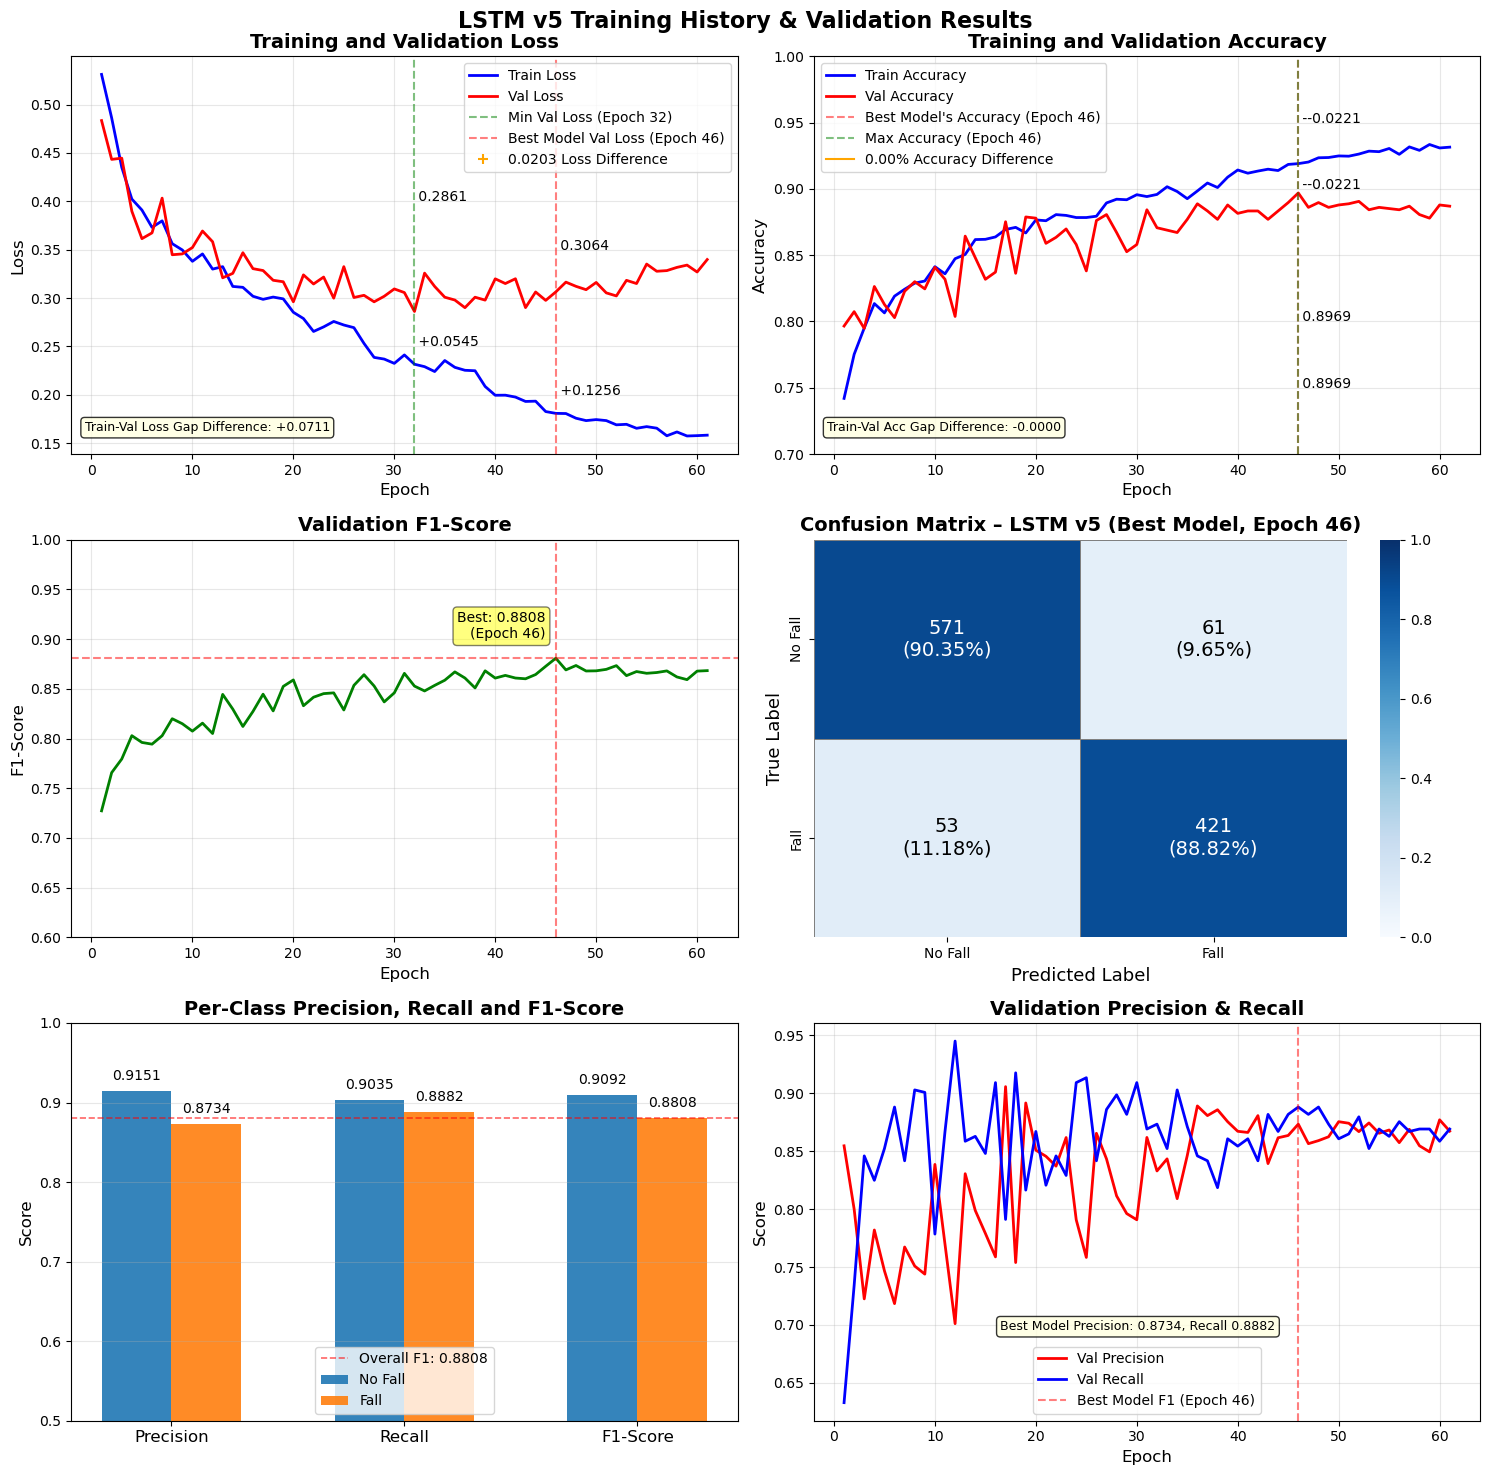

In [33]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D
import seaborn as sns

version = 'v5'
history_file = f'models/lstm_{version}/training_history.json'
val_results_file = f'models/lstm_{version}/validation_results.json'
save_dir = f'models/lstm_{version}'

# Load history
with open(history_file, 'r') as f:
    history = json.load(f)

with open(val_results_file, 'r') as f:
    results = json.load(f)
    
epochs = range(1, len(history['train_loss']) + 1)

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle(f'LSTM {version} Training History & Validation Results', fontsize=16, fontweight='bold')

# -----------------------------------------------------------------------
# Plot 1: Loss
axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')

# Find minimum validation loss
min_val_loss_idx = np.argmin(history['val_loss'])
min_val_loss = history['val_loss'][min_val_loss_idx]
train_val_loss_gap1 = min_val_loss-history['train_loss'][min_val_loss_idx]
axes[0, 0].axvline(x=min_val_loss_idx+1, color='g', linestyle='--', alpha=0.5, label=f'Min Val Loss (Epoch {min_val_loss_idx+1})')
axes[0, 0].text(min_val_loss_idx+1, 0.4, f' {min_val_loss:.4f}', ha='left', fontsize=10)
axes[0, 0].text(min_val_loss_idx+1, 0.25, f' +{train_val_loss_gap1:.4f}', ha='left', fontsize=10)

# Compare best epoch validation loss
best_epoch_idx = np.argmax(history['val_f1'])
best_val_loss = history['val_loss'][best_epoch_idx]
train_val_loss_gap2 = best_val_loss-history['train_loss'][best_epoch_idx]
axes[0, 0].axvline(x=best_epoch_idx+1, color='r', linestyle='--', alpha=0.5, label=f'Best Model Val Loss (Epoch {best_epoch_idx+1})')
axes[0, 0].text(best_epoch_idx+1, 0.35, f' {best_val_loss:.4f}', ha='left', fontsize=10)
axes[0, 0].text(best_epoch_idx+1, 0.2, f' +{train_val_loss_gap2:.4f}', ha='left', fontsize=10)
axes[0, 0].text(0.02, 0.05, f'Train-Val Loss Gap Difference: +{train_val_loss_gap2 - train_val_loss_gap1:.4f}', transform=axes[0, 0].transAxes, fontsize=9, va='bottom', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

axes[0, 0].legend(handles=[*axes[0, 0].get_legend_handles_labels()[0], 
                           Line2D([], [], color='none', marker='+', markersize=7, markeredgecolor='orange', markeredgewidth=1.5, label=f'{best_val_loss-min_val_loss:.4f} Loss Difference')],
                  fontsize=10, loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# -----------------------------------------------------------------------
# Plot 2: Accuracy
axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')

# Find best model's accuracy
max_acc_idx = np.argmax(history['val_acc'])
max_acc = history['val_acc'][max_acc_idx]
train_val_acc_gap1 = max_acc-history['train_acc'][max_acc_idx]
best_model_acc = history['val_acc'][best_epoch_idx]
train_val_acc_gap2 = best_model_acc-history['train_acc'][best_epoch_idx]
axes[0, 1].axvline(x=best_epoch_idx+1, color='r', linestyle='--', alpha=0.5, label=f'Best Model\'s Accuracy (Epoch {best_epoch_idx+1})')
axes[0, 1].text(best_epoch_idx+1, 0.8, f' {best_model_acc:.4f}', ha='left', fontsize=10)
axes[0, 1].text(best_epoch_idx+1, 0.95, f' -{train_val_acc_gap2:.4f}', ha='left', fontsize=10)
axes[0, 1].axvline(x=max_acc_idx+1, color='g', linestyle='--', alpha=0.5, label=f'Max Accuracy (Epoch {max_acc_idx+1})')
axes[0, 1].text(max_acc_idx+1, 0.75, f' {max_acc:.4f}', ha='left', fontsize=10)
axes[0, 1].text(max_acc_idx+1, 0.9, f' -{train_val_acc_gap1:.4f}', ha='left', fontsize=10)
axes[0, 1].plot([], [], color='orange', label=f'{(max_acc-best_model_acc)*100:.2f}% Accuracy Difference')
axes[0, 1].text(0.02, 0.05, f'Train-Val Acc Gap Difference: -{train_val_acc_gap1 - train_val_acc_gap2:.4f}', transform=axes[0, 1].transAxes, fontsize=9, va='bottom', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.7, 1.0])

# -----------------------------------------------------------------------
# Plot 3: F1-Score
axes[1, 0].plot(epochs, history['val_f1'], 'g-', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('F1-Score', fontsize=12)
axes[1, 0].set_title('Validation F1-Score', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.6, 1.0])

# Find best F1
best_f1_idx = np.argmax(history['val_f1'])
best_f1 = history['val_f1'][best_f1_idx]
axes[1, 0].axvline(x=best_f1_idx+1, color='r', linestyle='--', alpha=0.5)
axes[1, 0].axhline(y=best_f1, color='r', linestyle='--', alpha=0.5)
axes[1, 0].text(best_f1_idx, best_f1+0.02, f'Best: {best_f1:.4f}\n(Epoch {best_f1_idx+1})', ha='right', fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# -----------------------------------------------------------------------
# Plot 4: Confusion Matrix
cm = np.array(results['confusion_matrix'])
tn, fp = cm[0]
fn, tp = cm[1]

labels = ['No Fall', 'Fall']

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=False, cmap='Blues', xticklabels=labels, yticklabels=labels, linewidths=0.5, linecolor='grey', ax=axes[1, 1], vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = cm_norm[i, j] * 100
        colour = 'white' if cm_norm[i, j] > 0.5 else 'black'
        axes[1, 1].text(j + 0.5, i + 0.5, f'{count}\n({pct:.2f}%)', ha='center', va='center', fontsize=14, color=colour)

axes[1, 1].set_xlabel('Predicted Label', fontsize=13)
axes[1, 1].set_ylabel('True Label', fontsize=13)
axes[1, 1].set_title(f'Confusion Matrix – LSTM {version} (Best Model, Epoch {best_epoch_idx+1})', fontsize=14, fontweight='bold')

# -----------------------------------------------------------------------
# Plot 5: Individual Class Metrics
prec_nf = tn / (tn+fn)
rec_nf = tn / (tn+fp)
f1_nf = 2 * ((prec_nf*rec_nf)/(prec_nf+rec_nf))

prec_f = tp / (tp+fp)
rec_f = tp / (tp+fn)
f1_f = 2 * ((prec_f*rec_f)/(prec_f+rec_f))

metrics = ['Precision', 'Recall', 'F1-Score']
nf_vals = [prec_nf, rec_nf, f1_nf]
f_vals = [prec_f, rec_f, f1_f]

x = np.arange(len(metrics))
width = 0.3

bars_nf = axes[2, 0].bar(x - width/2, nf_vals, width, label='No Fall', alpha=0.9)
bars_f = axes[2, 0].bar(x + width/2, f_vals, width, label='Fall', alpha=0.9)

for bars in [bars_nf, bars_f]:
    for bar in bars:
        h = bar.get_height()
        axes[2, 0].text(bar.get_x() + (bar.get_width() / 2), h + 0.01, f'{h:.4f}', ha='center', va='bottom', fontsize=10)

axes[2, 0].axhline(y=results['f1_score'], color='red', linestyle='--', alpha=0.6, linewidth=1.2, label=f'Overall F1: {results["f1_score"]:.4f}')
axes[2, 0].set_xticks(x)
axes[2, 0].set_xticklabels(metrics, fontsize=12)
axes[2, 0].set_ylabel('Score', fontsize=12)
axes[2, 0].set_ylim(0.5, 1)
axes[2, 0].set_title('Per-Class Precision, Recall and F1-Score', fontsize=14, fontweight='bold')
axes[2, 0].legend(loc='lower center', fontsize=10)
axes[2, 0].grid(axis='y', alpha=0.3)

# -----------------------------------------------------------------------
# Plot 6: Precision-Recall over time
if version != 'v1':
    precision = results['precision']
    recall = results['recall']
    axes[2, 1].plot(epochs, history['val_precision'], 'r-', label='Val Precision', linewidth=2)
    axes[2, 1].plot(epochs, history['val_recall'], 'b-', label='Val Recall', linewidth=2)
    axes[2, 1].set_xlabel('Epoch', fontsize=12)
    axes[2, 1].set_ylabel('Score', fontsize=12)
    axes[2, 1].set_title('Validation Precision & Recall', fontsize=14, fontweight='bold')
    axes[2, 1].axvline(x=best_epoch_idx+1, color='r', linestyle='--', alpha=0.5, label=f'Best Model F1 (Epoch {best_epoch_idx+1})')
    axes[2, 1].text(0.28, 0.22, f'Best Model Precision: {precision:.4f}, Recall {recall:.4f}', transform=axes[2, 1].transAxes, fontsize=9, va='bottom', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[2, 1].legend(fontsize=10, loc='lower center')
    axes[2, 1].grid(True, alpha=0.3)
else:
    axes[2, 1].remove()

plt.tight_layout()

# Save figure
save_path = Path(save_dir)
plt.savefig(save_path / 'analysis_graphs.png', dpi=300, bbox_inches='tight')
print(f"! Analysis graphs saved to: {save_path / 'analysis_graphs.png'}")

plt.show()